<a href="https://colab.research.google.com/github/202204417/25-2-DIP-202204417/blob/main/HW_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1.라이브러리 임포트 및 데이터 로드**

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

h = pd.read_excel('diabet.xlsx')

X = h.iloc[:, :3].to_numpy()
X[:, 0] = 0.01 * X[:, 0] # plas
X[:, 1] = 0.01 * X[:, 1] # BMI
y = h.iloc[:, -1].to_numpy() # class label (-1 or 1)

print("데이터 형태:", X.shape)
print("초기 데이터 샘플:", X[:4])

데이터 형태: (60, 3)
초기 데이터 샘플: [[0.71  0.332 0.42 ]
 [0.71  0.28  0.59 ]
 [0.72  0.316 0.28 ]
 [0.74  0.297 0.29 ]]


**2.하이퍼파라미터 설정**

In [102]:
max_epoch_num = 2500

lr = 0.01

np.random.seed(0)
w = np.random.randn(4)

print(f"초기 파라미터 w: {w}")

초기 파라미터 w: [1.76405235 0.40015721 0.97873798 2.2408932 ]


**3.모델 학습**

In [103]:
W = np.zeros((4, max_epoch_num + 1))
W[:,0] = w
dw = 1e6
TH = 1e-6

X_tr = np.zeros((X.shape[0], X.shape[1] + 1))
X_tr[:, :3] = X
X_tr[:, 3] = 1

for n in range(max_epoch_num):
  w_old = w.copy()

  for i in range(len(X_tr)):
    y_hat_score = np.dot(w, X_tr[i])

    if y_hat_score <= 0 and y[i] == 1:
            w = w + lr * X_tr[i]

    elif y_hat_score >= 0 and y[i] == -1:
            w = w - lr * X_tr[i]
  W[:, n+1] = w

  dw = np.linalg.norm(w - w_old)
  if dw <= TH:
        print(f"Converged at epoch {n}")
        break

print("학습 완료.")
print("최종 학습된 파라미터 w:", w)

학습 완료.
최종 학습된 파라미터 w: [ 0.01265235  0.06285721  0.01783798 -0.0391068 ]


**4.결과 확인 및 정확도 계산**

최종 정확도(Accuracy): 93.33%


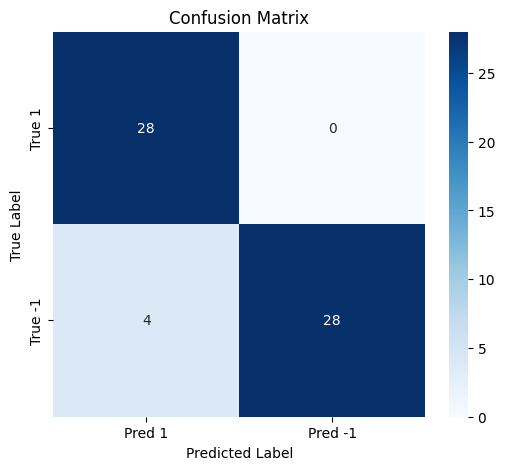

In [104]:
y_pred = np.zeros_like(y)

for i in range(len(X_tr)):
    y_hat_score = np.dot(w, X_tr[i])
    if y_hat_score >= 0:
        y_pred[i] = 1
    else:
        y_pred[i] = -1

C = np.zeros((2, 2))

for i in range(len(y)):
    if y[i] == 1 and y_pred[i] == 1:
        C[0, 0] += 1
    elif y[i] == -1 and y_pred[i] == -1:
        C[1, 1] += 1
    elif y[i] == 1 and y_pred[i] == -1:
        C[0, 1] += 1
    elif y[i] == -1 and y_pred[i] == 1:
        C[1, 0] += 1

acc = (C[0, 0] + C[1, 1]) / len(y)
print(f'최종 정확도(Accuracy): {acc * 100:.2f}%')

plt.figure(figsize=(6, 5))
sns.heatmap(C, annot=True, fmt='g', cmap='Blues',
            xticklabels=['Pred 1', 'Pred -1'],
            yticklabels=['True 1', 'True -1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

**5.파라미터 변화 그래프 출력**

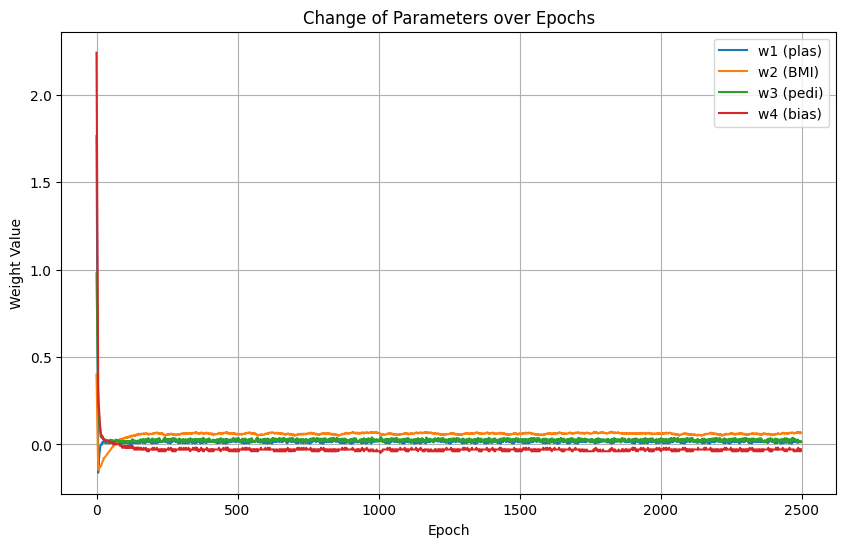

In [105]:
plt.figure(figsize=(10, 6))
plt.plot(W[0, :n], label='w1 (plas)')
plt.plot(W[1, :n], label='w2 (BMI)')
plt.plot(W[2, :n], label='w3 (pedi)')
plt.plot(W[3, :n], label='w4 (bias)')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Weight Value')
plt.title('Change of Parameters over Epochs')
plt.grid(True)
plt.show()